# C08 — Compressed Sensing
### MRI: Zero to Hero · Module 4 (Advanced Reconstruction) · CMRI Lecture 8

**What this notebook does:** builds compressed sensing (CS) for MRI from the ground up — the three ingredients (**sparsity, incoherence, non-linear reconstruction**) — and ends with the full **Lab 8** exercises *plus worked solutions*.

By the end you will be able to:
- Show *why* MR images can be recovered from far fewer samples than Nyquist demands.
- Use **wavelets** and **finite differences / total variation** as sparsifying transforms.
- Explain **incoherence** and measure it with the (transform) point-spread function.
- Implement **iterative soft-thresholding (ISTA)** and reconstruct an image from randomly undersampled k-space.
- Reason about the regularization parameter **λ** and the limits of CS image quality.

> Everything runs on a **synthetic phantom** so no download is needed. An optional *"try it on real data"* cell points you at fastMRI / IXI for later.


## 0 · Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'gray'

# ---- centered, orthonormal 2D Fourier transform (k-space <-> image) ----
def fft2c(x):  return np.fft.fftshift(np.fft.fft2 (np.fft.ifftshift(x), norm='ortho'))
def ifft2c(X): return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(X), norm='ortho'))

# ---- wavelet transform helpers (4-tap Daubechies, the lab's choice) ----
WAVE, LEVEL, MODE = 'db4', 4, 'periodization'
def wave_fwd(img):
    "image -> (flat coeff array, slice metadata)"
    return pywt.coeffs_to_array(pywt.wavedec2(img, WAVE, level=LEVEL, mode=MODE))
def wave_inv(arr, slices):
    "(flat coeff array, slices) -> image"
    coeffs = pywt.array_to_coeffs(arr, slices, output_format='wavedec2')
    return pywt.waverec2(coeffs, WAVE, mode=MODE)

def imshow_row(imgs, titles, cmap='gray', vmax=None):
    fig, ax = plt.subplots(1, len(imgs), figsize=(3.2*len(imgs), 3.4))
    if len(imgs) == 1: ax = [ax]
    for a, im, t in zip(ax, imgs, titles):
        a.imshow(np.abs(im), cmap=cmap, vmax=vmax); a.set_title(t); a.axis('off')
    plt.tight_layout(); plt.show()

print("Setup complete. PyWavelets", pywt.__version__)

Setup complete. PyWavelets 1.8.0


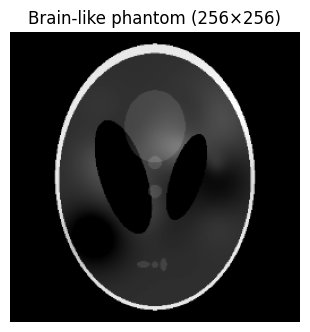

In [2]:
# ---- a brain-LIKE phantom: Shepp-Logan + smooth intensity texture ----
# (real medical images are not literally sparse, but they ARE compressible)
def brain_phantom(n=256, seed=0):
    rng = np.random.default_rng(seed)
    ph = resize(shepp_logan_phantom(), (n, n), anti_aliasing=True)
    yy, xx = np.mgrid[0:n, 0:n]
    tex = np.zeros((n, n))
    for _ in range(40):
        cy, cx = rng.uniform(n*0.25, n*0.75, 2)
        s, a = rng.uniform(6, 22), rng.uniform(-0.12, 0.12)
        tex += a*np.exp(-((yy-cy)**2 + (xx-cx)**2)/(2*s**2))
    return np.clip(ph + (ph > 0.05)*tex, 0, None)

N = 256
img = brain_phantom(N)
imshow_row([img], ["Brain-like phantom (256×256)"])

## 1 · The big picture — Nyquist is wasteful

**The classic pipeline is:** sample at the **Nyquist rate** → reconstruct → *then* compress (JPEG-2000 throws away most coefficients). The slide's question is the whole point:

> *Why acquire samples at the Nyquist rate if we are going to throw away most of them?*

**Compressed sensing answer:** *don't.* Build the compression **into the acquisition** — first compress, then reconstruct. The handwritten note on the slide says it cleanly: a sparse image needs **fewer coefficients than the original**, so it should need **fewer samples**.

Below: the phantom is not sparse in the **pixel** domain, but its **gradient** (and its wavelet transform) is — only a few coefficients are non-zero.

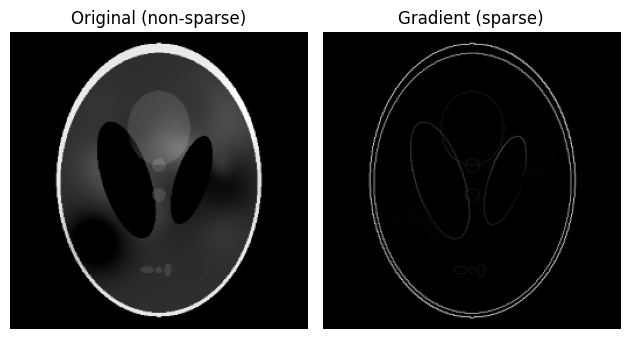

non-zero pixels in image :  41.4% of pixels
non-zero in gradient     :  31.1% of pixels


In [3]:
# finite-difference (gradient) image: sparse for piecewise-smooth images
gx = np.diff(img, axis=1, prepend=img[:, :1])
gy = np.diff(img, axis=0, prepend=img[:1, :])
grad_mag = np.sqrt(gx**2 + gy**2)
imshow_row([img, grad_mag], ["Original (non-sparse)", "Gradient (sparse)"])
print(f"non-zero pixels in image : {(img>1e-3).mean()*100:5.1f}% of pixels")
print(f"non-zero in gradient     : {(grad_mag>1e-3).mean()*100:5.1f}% of pixels")

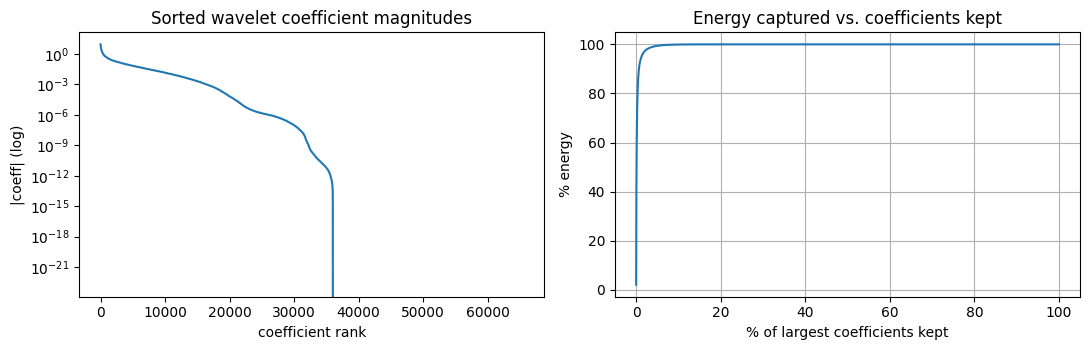

Top 5% of wavelet coefficients hold 99.4% of the image energy.


In [4]:
# How concentrated is the WAVELET representation? Plot coefficient-magnitude decay.
arr, slices = wave_fwd(img)
mags = np.sort(np.abs(arr).ravel())[::-1]
energy = np.cumsum(mags**2) / np.sum(mags**2)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].semilogy(mags); ax[0].set_title("Sorted wavelet coefficient magnitudes")
ax[0].set_xlabel("coefficient rank"); ax[0].set_ylabel("|coeff| (log)")
ax[1].plot(100*np.arange(len(energy))/len(energy), 100*energy)
ax[1].set_title("Energy captured vs. coefficients kept")
ax[1].set_xlabel("% of largest coefficients kept"); ax[1].set_ylabel("% energy"); ax[1].grid(True)
plt.tight_layout(); plt.show()
k = int(0.05*arr.size)
print(f"Top 5% of wavelet coefficients hold {100*energy[k]:.1f}% of the image energy.")

## 2 · Ingredient #1 — Sparsity & sparsifying transforms

A transform **T** is *sparsifying* if **T·m** has only a few large coefficients. The lecture lists:

**Finite differences** $y(n)=x(n)-x(n-1)$, i.e. $y = Dx$ with the bidiagonal matrix $D=\begin{bmatrix}1&-1&&\\&1&-1&\\&&1&-1\end{bmatrix}$

**Total variation** $TV(x)=\sum_n |x(n)-x(n-1)| = \lVert Dx\rVert_1$ — so *minimising TV = minimising the ℓ₁ norm of the finite differences*. The slide's table shows TV **grows** as you take fewer radial spokes (256² original = 2801 a.u. → 32 spokes = 8281 a.u.): undersampling injects streak artifacts that raise TV, so penalising TV pushes them back out.

**Wavelets** give a multi-resolution representation (the JPEG-2000 transform). The handwritten note: *"# non-zero: B≪A, ℓ²-norm: B≈A"* — the wavelet image **B** has far fewer non-zeros than the pixel image **A**, while holding nearly the same energy. That gap is exactly what CS exploits.

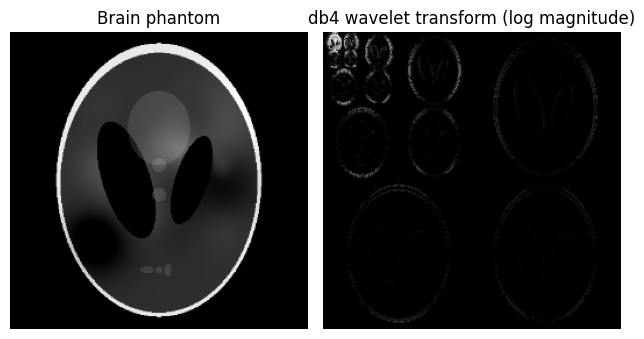

l1-norm  image domain :   8030.0
l1-norm  wavelet domain:   2313.9   <- smaller => sparser representation


In [5]:
# Wavelet subbands of the phantom (db4, 4 levels)
arr, slices = wave_fwd(img)
disp = np.log1p(np.abs(arr))
imshow_row([img, disp], ["Brain phantom", "db4 wavelet transform (log magnitude)"])

l1_img  = np.abs(img).sum()
l1_wave = np.abs(arr).sum()
print(f"l1-norm  image domain : {l1_img:8.1f}")
print(f"l1-norm  wavelet domain: {l1_wave:8.1f}   <- smaller => sparser representation")

In [6]:
# Total variation rises as we keep fewer radial-like samples (slide's table, recreated)
def radial_mask(n, n_spokes, seed=0):
    rng = np.random.default_rng(seed); m = np.zeros((n, n)); c = n//2
    for theta in np.linspace(0, np.pi, n_spokes, endpoint=False):
        t = np.linspace(-c, c, 2*n)
        ys = np.clip((c + t*np.sin(theta)).astype(int), 0, n-1)
        xs = np.clip((c + t*np.cos(theta)).astype(int), 0, n-1)
        m[ys, xs] = 1
    return m

def total_variation(x):
    return np.abs(np.diff(x, axis=0)).sum() + np.abs(np.diff(x, axis=1)).sum()

ksp_full = fft2c(img.astype(complex))
print(f"{'data set':22s}{'Total Variation (a.u.)':>22s}")
print(f"{'Original (256x256)':22s}{total_variation(img):22.0f}")
for spokes in [128, 64, 32]:
    rec = np.abs(ifft2c(radial_mask(N, spokes)*ksp_full))
    print(f"{str(spokes)+' spokes':22s}{total_variation(rec):22.0f}")

data set              Total Variation (a.u.)
Original (256x256)                      1710
128 spokes                              3234
64 spokes                               3479
32 spokes                               3019


## 3 · Ingredient #2 — Incoherence

Undersampling always creates aliasing. The trick is to make the aliasing **incoherent** — *"it has statistics like noise"* (slide annotation) — instead of structured copies of the object. Noise-like artifacts can be removed by a denoiser; coherent replicas cannot.

- **Regular** undersampling → **coherent** aliasing (clean fold-over copies). Deterministic — *"but you can find its pattern."*
- **Random** undersampling → **incoherent**, noise-like aliasing. This is what CS wants.

The diagnostic is the **(Transform) Point-Spread Function (TPSF)**: take the inverse FFT of the sampling mask, (optionally) apply the sparsifying transform, and look at the ratio of the **main peak** to the **side-lobe floor**. A single sharp peak on a low noisy floor = incoherent.

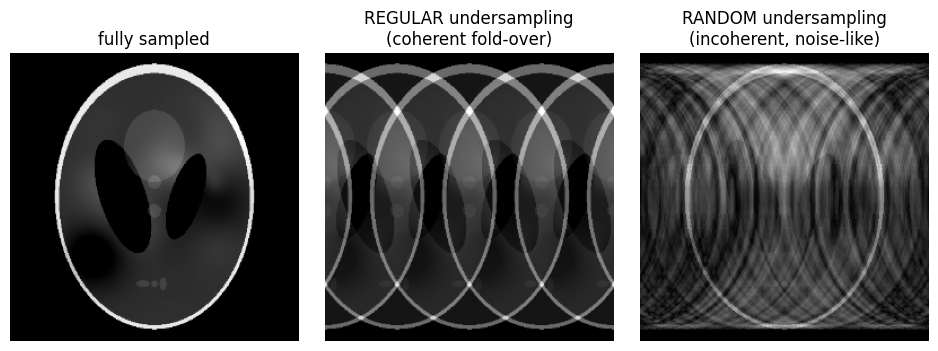

In [7]:
# Coherent vs incoherent aliasing: zero-filled reconstructions
def regular_cols(n, R): m = np.zeros((n, n)); m[:, ::R] = 1; return m
def random_cols(n, R, seed=0):
    rng = np.random.default_rng(seed); col = rng.random(n) < 1/R
    m = np.zeros((n, n)); m[:, col] = 1; return m

mreg, mrnd = regular_cols(N, 4), random_cols(N, 4)
rec_reg = ifft2c(mreg*ksp_full)
rec_rnd = ifft2c(mrnd*ksp_full)
imshow_row([img, rec_reg, rec_rnd],
           ["fully sampled", "REGULAR undersampling\n(coherent fold-over)",
            "RANDOM undersampling\n(incoherent, noise-like)"])

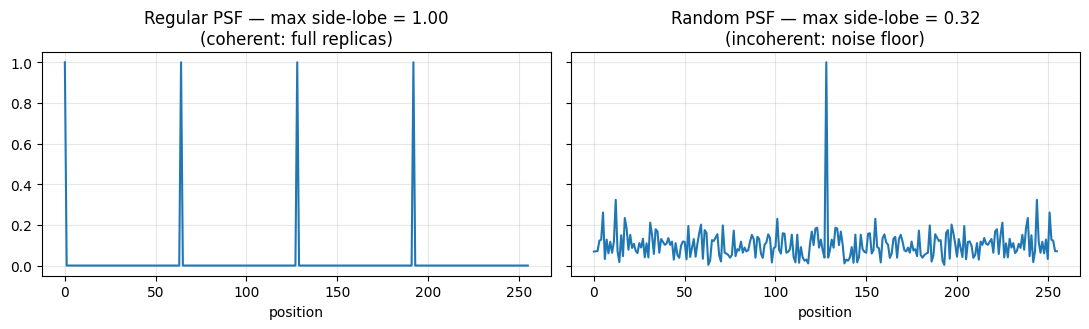

In [8]:
# Point-spread function of the two 1D sampling patterns
def psf_1d(colmask):
    p = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(colmask.astype(float)))))
    return p/p.max()
def max_sidelobe(p):
    c = len(p)//2; q = p.copy(); q[c-1:c+2] = 0; return q.max()

p_reg, p_rnd = psf_1d(mreg[0]), psf_1d(mrnd[0])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
ax[0].plot(p_reg); ax[0].set_title(f"Regular PSF — max side-lobe = {max_sidelobe(p_reg):.2f}\n(coherent: full replicas)")
ax[1].plot(p_rnd); ax[1].set_title(f"Random PSF — max side-lobe = {max_sidelobe(p_rnd):.2f}\n(incoherent: noise floor)")
for a in ax: a.set_xlabel("position"); a.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

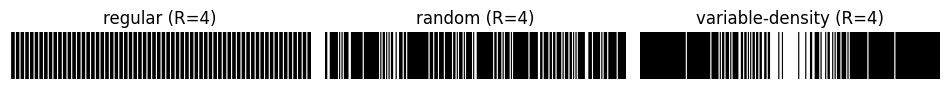

variable-density acceleration R = 4.00


In [8]:
# In practice: VARIABLE-DENSITY random sampling — dense centre (contrast/energy),
# random periphery (incoherence). Best of both worlds; also note higher matrix
# size => MORE incoherence (handwritten: "dimensionality up => incoherence up").
def variable_density_mask(n, R, center=12, sigma_div=8, seed=0):
    rng = np.random.default_rng(seed); ky = np.arange(n) - n//2
    p = np.exp(-(ky**2)/(2*(n/sigma_div)**2)); p /= p.sum()
    col = np.zeros(n, bool); c = n//2; col[c-center//2:c+center//2] = True
    while col.sum() < n/R:
        col[rng.choice(n, p=p)] = True
    m = np.zeros((n, n)); m[:, col] = 1; return m

mvd = variable_density_mask(N, 4)
imshow_row([np.tile(mreg[0], (40,1)), np.tile(random_cols(N,4)[0],(40,1)), np.tile(mvd[0],(40,1))],
           ["regular (R=4)", "random (R=4)", "variable-density (R=4)"])
print(f"variable-density acceleration R = {mvd.size/mvd.sum():.2f}")

## 4 · The simple CS example (1-D spikes)

This is the slide's toy: a signal with **three spikes** is sampled in k-space, then **randomly undersampled**. The aliasing is incoherent, so a tiny iterative recipe recovers the spikes exactly:

1. **threshold** so the largest impulses survive, 2. **apply** the undersampling (data consistency), 3. **subtract**, 4. **threshold again** — repeat (slide: *A − B ⊂ C*).

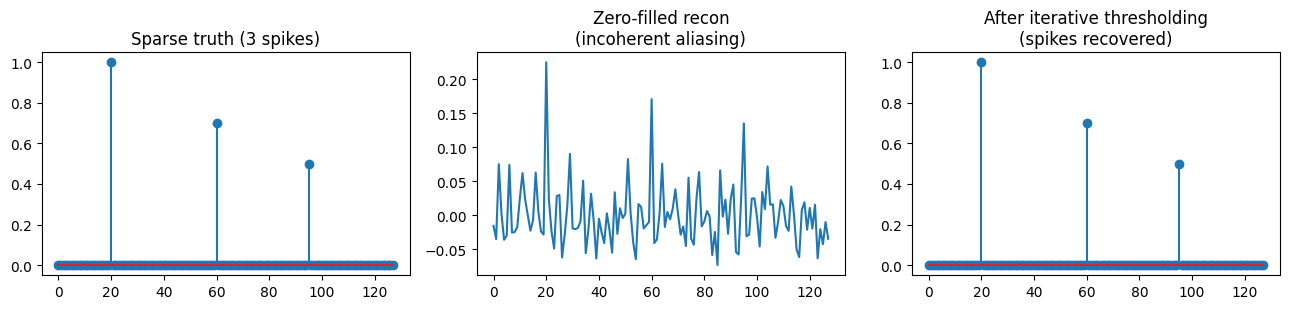

recovered from 32/128 samples; max error = 8.67e-06


In [9]:
def cs_toy_1d(n=128, n_keep=3, R=4, n_iter=60, seed=1):
    rng = np.random.default_rng(seed)
    x = np.zeros(n); x[[20, 60, 95]] = [1.0, 0.7, 0.5]      # sparse truth
    X = np.fft.fft(x)
    mask = np.zeros(n, bool); mask[rng.choice(n, n//R, replace=False)] = True
    d = np.zeros(n, complex); d[mask] = X[mask]             # undersampled k-space
    est = np.zeros(n, complex)
    for _ in range(n_iter):
        est = est - np.fft.ifft(mask*(np.fft.fft(est) - d)) # data consistency
        thr = np.sort(np.abs(est))[::-1][n_keep]            # keep n_keep largest
        est = est*(np.abs(est) > thr)
    return x, np.real(est), mask, np.real(np.fft.ifft(d))

x, est, mask, zerofill = cs_toy_1d()
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].stem(x); ax[0].set_title("Sparse truth (3 spikes)")
ax[1].plot(zerofill); ax[1].set_title("Zero-filled recon\n(incoherent aliasing)")
ax[2].stem(est); ax[2].set_title("After iterative thresholding\n(spikes recovered)")
plt.tight_layout(); plt.show()
print(f"recovered from {mask.sum()}/{len(x)} samples; max error = {np.abs(x-est).max():.2e}")

## 5 · Ingredient #3 — Non-linear reconstruction (iterative soft-thresholding)

CS reconstruction solves (with **E** the undersampled Fourier operator, **d** the data, **T** the sparsifying transform):

$$\min_{m}\ \tfrac12\lVert \mathbf{E m - d}\rVert_2^2 \;+\; \lambda\,\lVert \mathbf{T m}\rVert_1$$

The first term is **data consistency** (the image must explain the measurements); the second is **sparsity**. **λ** is the *weighting parameter that makes the balance* (slide annotation):
- **high λ** → strong artifact/noise removal but image corruption (blur, ringing, blocking);
- **low λ** → no corruption but residual aliasing.

The ℓ₁ term is **non-differentiable at 0**, so plain gradient descent fails. The fix is **proximal** gradient descent — a data-consistency gradient step followed by the **soft-thresholding** operator in the sparse domain:

$$\mathbf{m}_{n+1} = \mathbf{T}^{-1}\Big[\,S\big(\mathbf{T}[\mathbf{m}_n - \mathbf{E}^H(\mathbf{E m}_n-\mathbf d)]\,,\ \lambda\big)\Big],\qquad
S(x,\lambda)=\begin{cases}0 & |x|\le\lambda\\ \frac{x}{|x|}(|x|-\lambda) & |x|>\lambda\end{cases}$$

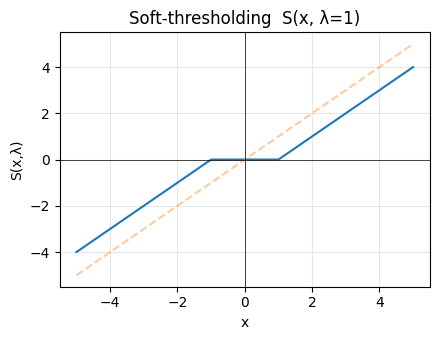

In [10]:
def soft_threshold(x, T):
    "complex-aware soft-thresholding S(x, T)"
    mag = np.abs(x)
    return np.where(mag > T, x*(mag - T)/np.maximum(mag, 1e-12), 0)

t = np.linspace(-5, 5, 500)
plt.figure(figsize=(4.5, 3.5))
plt.plot(t, np.real(soft_threshold(t.astype(complex), 1.0)))
plt.plot(t, t, '--', alpha=.4); plt.axhline(0, color='k', lw=.5); plt.axvline(0, color='k', lw=.5)
plt.title("Soft-thresholding  S(x, λ=1)"); plt.xlabel("x"); plt.ylabel("S(x,λ)")
plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

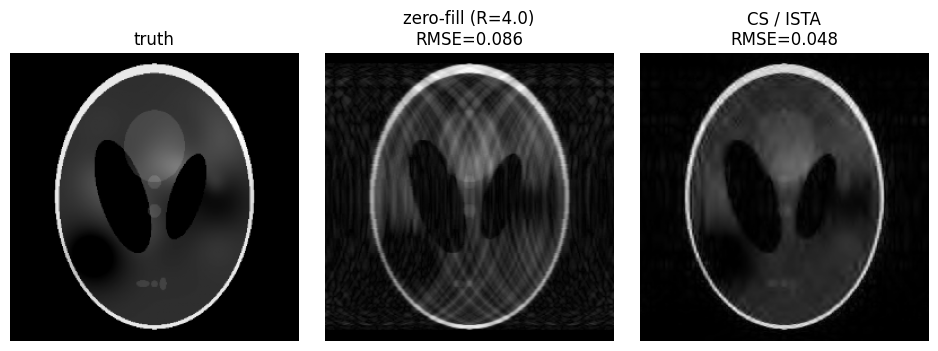

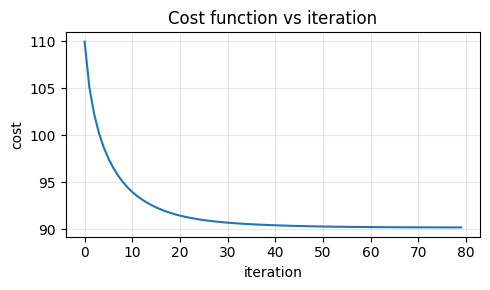

In [11]:
def cs_ista(d, mask, lam_frac, n_iter=80):
    # Iterative soft-thresholding (ISTA) for masked-Fourier CS.
    # lam_frac: threshold as a fraction of the max coeff of the zero-filled solution.
    m = ifft2c(d)
    a0, _ = wave_fwd(np.abs(ifft2c(d)))
    T = lam_frac*np.abs(a0).max()
    cost = []
    for _ in range(n_iter):
        m = m - ifft2c(mask*fft2c(m) - d)        # data-consistency gradient step
        arr, slices = wave_fwd(m)                # to sparse domain
        arr = soft_threshold(arr, T)             # threshold
        m = wave_inv(arr, slices)                # back to image
        dc = np.linalg.norm((mask*fft2c(m) - d).ravel())**2
        cost.append(dc + T*np.abs(wave_fwd(m)[0]).sum())
    return m, cost

truth = brain_phantom(N)
ksp   = fft2c(truth.astype(complex))
mask  = variable_density_mask(N, 4)
d     = mask*ksp
R     = mask.size/mask.sum()

zf = np.abs(ifft2c(d))
rec, cost = cs_ista(d, mask, lam_frac=0.005, n_iter=80)
rmse = lambda a: np.sqrt(np.mean((np.abs(a) - truth)**2))
imshow_row([truth, zf, np.abs(rec)],
           ["truth", f"zero-fill (R={R:.1f})\nRMSE={rmse(zf):.3f}",
            f"CS / ISTA\nRMSE={rmse(rec):.3f}"])
plt.figure(figsize=(5,3)); plt.plot(cost); plt.title("Cost function vs iteration")
plt.xlabel("iteration"); plt.ylabel("cost"); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

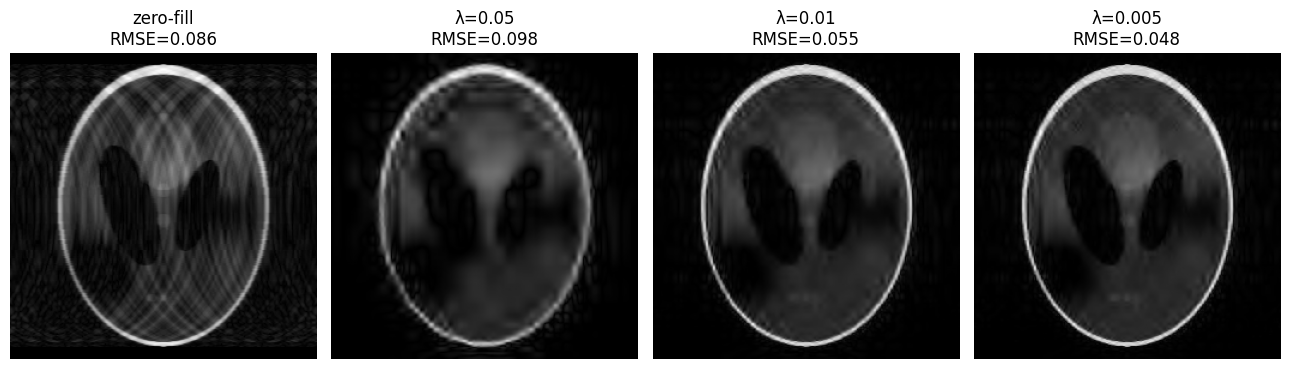

In [12]:
# The lambda trade-off (slide 21): too high -> blur/over-smooth; too low -> residual aliasing
fig, ax = plt.subplots(1, 4, figsize=(13, 3.6))
ax[0].imshow(zf, cmap='gray'); ax[0].set_title(f"zero-fill\nRMSE={rmse(zf):.3f}"); ax[0].axis('off')
for a, lam in zip(ax[1:], [0.05, 0.01, 0.005]):
    r, _ = cs_ista(d, mask, lam_frac=lam, n_iter=80)
    a.imshow(np.abs(r), cmap='gray'); a.set_title(f"λ={lam}\nRMSE={rmse(r):.3f}"); a.axis('off')
plt.tight_layout(); plt.show()

## 6 · A note on image quality

The lecture warns: **SNR is not a good metric** for CS. Soft-thresholding discards small coefficients, which can cause **loss of contrast, blurring, blockiness, ringing**, and an over-smoothed *"synthetic"* look — even when the SNR number looks great. Evaluate CS images with task-relevant criteria (can you still see the lesion?), not SNR alone.

**CS + parallel imaging.** Sparsity and coil-sensitivity encoding are *complementary* information, so CS regularizes the parallel-imaging inverse problem while PI suppresses incoherent aliasing. The catch: CS wants *irregular* sampling, PI likes *regular* sampling — **Poisson-disc** patterns are the usual compromise. Joint CS&PI (e.g. ℓ₁-SPIRiT) gives the cleanest images at high acceleration.

---
### Optional · try it on real data
Swap the phantom for a real slice once you have data locally (this cell won't run in a sandbox without the file):
```python
# import nibabel as nib
# vol = nib.load("IXI002-Guys-0828-T1.nii.gz").get_fdata()
# truth = resize(vol[:, :, vol.shape[2]//2], (256, 256))
# ...then rerun sections 5-6 with this `truth`.
# fastMRI raw k-space: https://fastmri.med.nyu.edu/   IXI: https://brain-development.org/ixi-dataset/
```


---
# Lab 8 — Exercises

Recreated from *Computational MR Imaging, Laboratory 8: Compressed Sensing*. In the real lab you load `data_lab8.mat` (`kfull`, `kacc`); here we synthesise the equivalents so the exercises run standalone. **Try them yourself first** — full solutions follow further down.

```python
# Real-lab loading (for reference):
# from scipy.io import loadmat
# data = loadmat('data_lab8.mat'); kfull, kacc = data['kfull'], data['kacc']
```

In [13]:
# ---- synthetic stand-ins for the lab's data_lab8.mat ----
kfull = fft2c(brain_phantom(256).astype(complex))      # fully-sampled k-space
kacc  = variable_density_mask(256, 4) * kfull          # variable-density undersampled
sampling_mask = (np.abs(kacc) > 0)                     # 1 = sampled
print("kfull:", kfull.shape, " | sampled fraction of kacc:", sampling_mask.mean().round(3))

kfull: (256, 256)  | sampled fraction of kacc: 0.25


### Exercise 1 — Sparsity / compressibility with the wavelet transform
1.1 Use `dwt2`/`idwt2` (here: `wave_fwd`/`wave_inv` with **db4**).
1.2 (Data already loaded above.)
1.3 Reconstruct `kfull` and plot the image **and** its wavelet representation.
1.4 Compute the **ℓ₁-norm** of both — which is sparser?
1.5 Write `compress(coeff_arr, comp_factor)`: keep only the largest `N/comp_factor` coefficients (hard threshold).
1.6 Compress the brain image by factors **5, 10, 20**.
1.7 Plot the compressed images and their **error images**.
1.8 Compute the **RMSE** for each ratio. Which would you choose? What's the max CS acceleration this suggests?

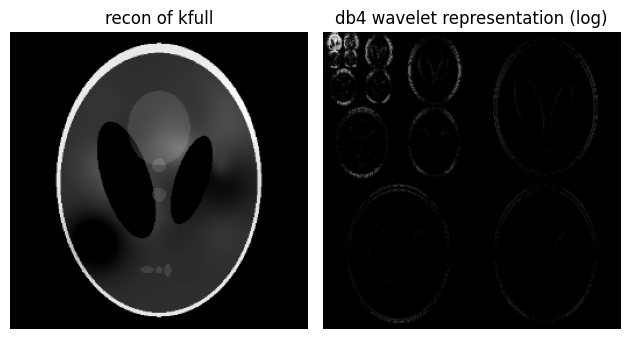

l1 image domain   :    8030.0
l1 wavelet domain :    2313.9   -> wavelet is far sparser

  factor   kept coeffs      RMSE
       5         13107    0.0006
      10          6553    0.0066
      20          3276    0.0190


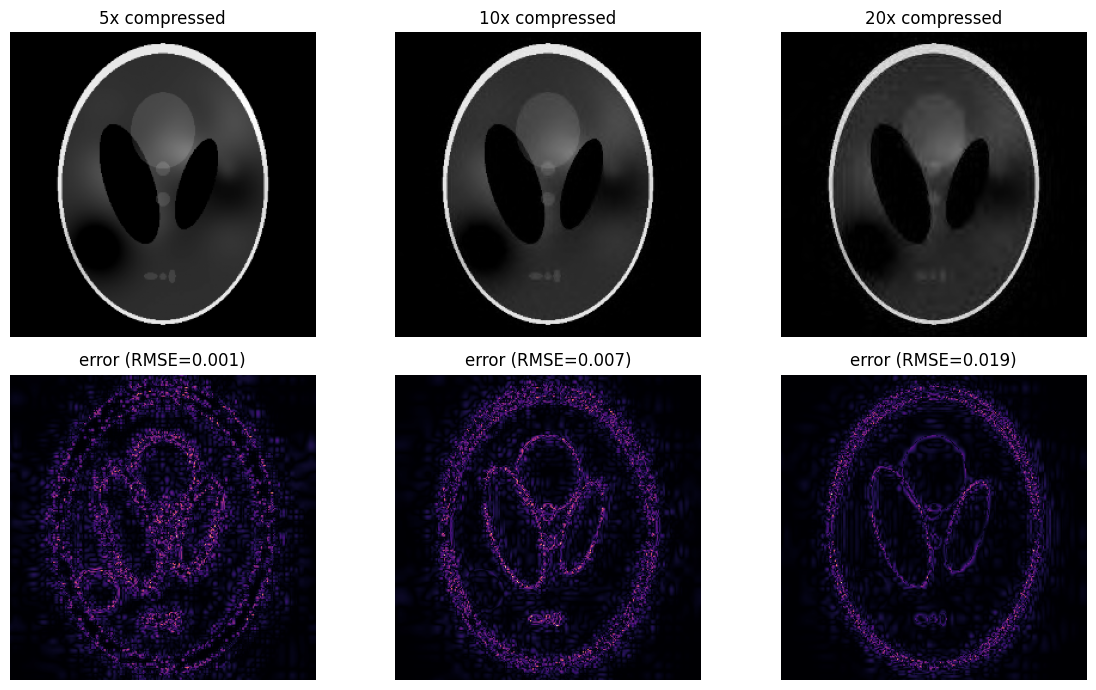

In [14]:
# 1.3 reconstruct kfull and show its wavelet representation
img1 = np.abs(ifft2c(kfull))
arr1, slices1 = wave_fwd(img1)
imshow_row([img1, np.log1p(np.abs(arr1))], ["recon of kfull", "db4 wavelet representation (log)"])

# 1.4 l1-norms
print(f"l1 image domain   : {np.abs(img1).sum():9.1f}")
print(f"l1 wavelet domain : {np.abs(arr1).sum():9.1f}   -> wavelet is far sparser\n")

# 1.5 compress(): keep the largest N/comp_factor coefficients
def compress(coeff_arr, comp_factor):
    N = coeff_arr.size
    keep = max(1, N // comp_factor)
    T = np.sort(np.abs(coeff_arr).ravel())[::-1][keep-1]
    return coeff_arr * (np.abs(coeff_arr) >= T)

# 1.6 / 1.7 / 1.8 compress by 5, 10, 20; plot images + errors; RMSE
factors = [5, 10, 20]
fig, ax = plt.subplots(2, len(factors), figsize=(4*len(factors), 7))
print(f"{'factor':>8s}{'kept coeffs':>14s}{'RMSE':>10s}")
for j, cf in enumerate(factors):
    arr_c = compress(arr1, cf)
    rec_c = wave_inv(arr_c, slices1)
    err   = np.abs(rec_c - img1)
    rmse  = np.sqrt(np.mean(err**2))
    print(f"{cf:>8d}{int((np.abs(arr_c)>0).sum()):>14d}{rmse:>10.4f}")
    ax[0, j].imshow(np.abs(rec_c), cmap='gray'); ax[0, j].set_title(f"{cf}x compressed"); ax[0, j].axis('off')
    ax[1, j].imshow(err, cmap='magma');          ax[1, j].set_title(f"error (RMSE={rmse:.3f})"); ax[1, j].axis('off')
plt.tight_layout(); plt.show()

### Exercise 2 — CS reconstruction with iterative soft-thresholding
2.1 Plot the undersampling pattern of `kacc` and compute the **acceleration factor**.
2.2 Write `soft_threshold(coeff_arr, T)`.
2.3 Implement **iterative soft-thresholding** with the db4 wavelet transform.
2.4 Reconstruct `kacc`. Pick **λ ≈ 1% of the max coefficient of the initial solution**; also try **λ = 5%, 1%, 0.5%**. Plot the initial solution, final reconstruction and error images vs. the fully-sampled one, and the **cost function** per iteration.

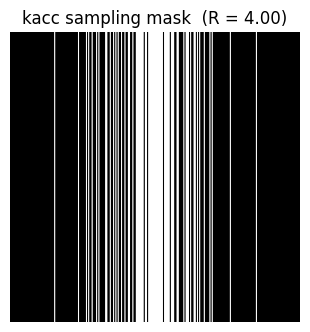

acceleration factor R = 4.00


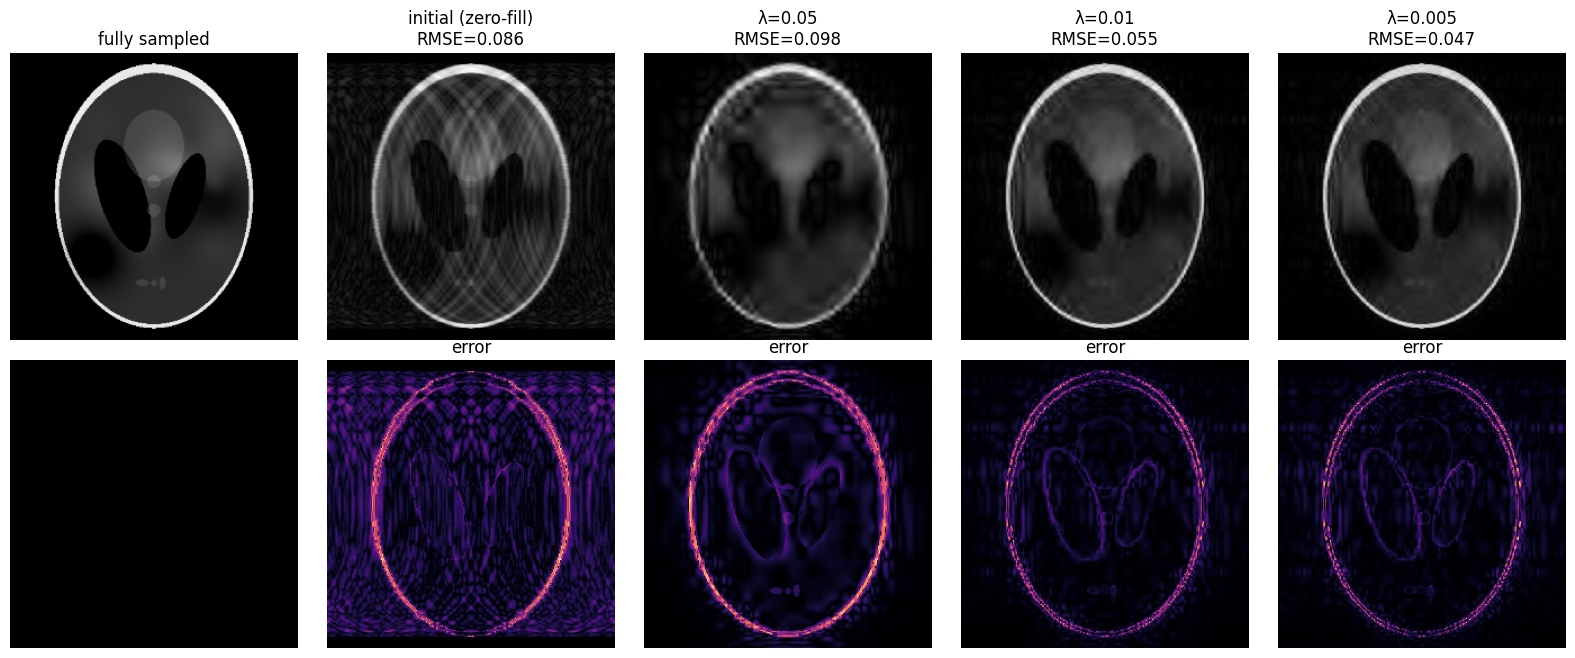

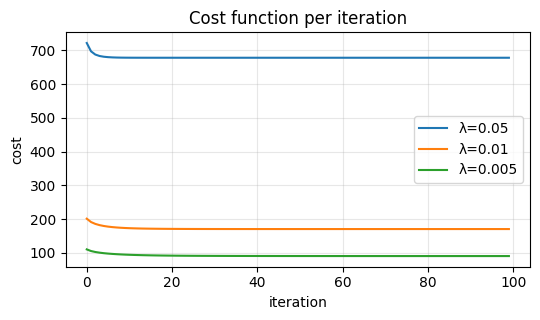

In [15]:
# 2.1 undersampling pattern + acceleration factor
acc = sampling_mask.size / sampling_mask.sum()
imshow_row([sampling_mask], [f"kacc sampling mask  (R = {acc:.2f})"])
print(f"acceleration factor R = {acc:.2f}")

# 2.2 soft_threshold (complex-aware) -- already defined in Section 5, repeated for completeness
def soft_threshold(coeff_arr, T):
    mag = np.abs(coeff_arr)
    return np.where(mag > T, coeff_arr*(mag - T)/np.maximum(mag, 1e-12), 0)

# 2.3 iterative soft-thresholding with db4
def ist_reconstruct(kacc, mask, lam_frac, n_iter=100):
    m = ifft2c(kacc)
    T = lam_frac*np.abs(wave_fwd(np.abs(m))[0]).max()      # threshold ~ % of max init coeff
    cost = []
    for _ in range(n_iter):
        m = m - ifft2c(mask*fft2c(m) - kacc)               # data consistency
        a, s = wave_fwd(m)
        a = soft_threshold(a, T)
        m = wave_inv(a, s)
        cost.append(np.linalg.norm((mask*fft2c(m) - kacc).ravel())**2 + T*np.abs(wave_fwd(m)[0]).sum())
    return m, cost

# 2.4 reconstruct kacc, sweep lambda = 5%, 1%, 0.5%
truth2 = np.abs(ifft2c(kfull))
init   = np.abs(ifft2c(kacc))
rmse2  = lambda a: np.sqrt(np.mean((np.abs(a) - truth2)**2))

fig, ax = plt.subplots(2, 5, figsize=(16, 6.6))
ax[0,0].imshow(truth2, cmap='gray'); ax[0,0].set_title("fully sampled"); ax[0,0].axis('off')
ax[1,0].imshow(np.zeros_like(truth2), cmap='magma'); ax[1,0].axis('off')
ax[0,1].imshow(init, cmap='gray'); ax[0,1].set_title(f"initial (zero-fill)\nRMSE={rmse2(init):.3f}"); ax[0,1].axis('off')
ax[1,1].imshow(np.abs(init-truth2), cmap='magma'); ax[1,1].set_title("error"); ax[1,1].axis('off')

curves = {}
for j, lam in enumerate([0.05, 0.01, 0.005], start=2):
    rec, cost = ist_reconstruct(kacc, sampling_mask, lam_frac=lam, n_iter=100)
    curves[lam] = cost
    ax[0,j].imshow(np.abs(rec), cmap='gray'); ax[0,j].set_title(f"λ={lam}\nRMSE={rmse2(rec):.3f}"); ax[0,j].axis('off')
    ax[1,j].imshow(np.abs(np.abs(rec)-truth2), cmap='magma'); ax[1,j].set_title("error"); ax[1,j].axis('off')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5.5,3.3))
for lam, c in curves.items(): plt.plot(c, label=f"λ={lam}")
plt.title("Cost function per iteration"); plt.xlabel("iteration"); plt.ylabel("cost")
plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

**Reading the λ sweep.** **λ=5%** over-regularises — aliasing is gone but the image is blurred/blocky and RMSE can be *worse* than zero-fill. **λ=0.5–1%** is the sweet spot here: incoherent aliasing is suppressed while edges survive, and RMSE drops well below the zero-filled solution. This is exactly the slide-21 trade-off, and the *"≈1% of the max initial coefficient"* rule of thumb lands right in the useful range.

---
## Self-test
1. Why is acquiring at the Nyquist rate "wasteful" for a compressible image?
2. Name the three ingredients of CS and what each one contributes.
3. Why does **random** undersampling beat **regular** undersampling for CS?
4. What does **total variation** minimisation correspond to, in terms of the ℓ₁ norm?
5. Why can't we use plain gradient descent on the ℓ₁ term, and what replaces it?
6. What happens to the image as **λ → large**? As **λ → 0**?
7. Why is **SNR** a poor quality metric for CS reconstructions?
8. Why do CS and parallel imaging have *conflicting* sampling requirements, and what pattern reconciles them?

*(Answers are worked through in the sections above.)*